# Correlation Matrix Between Feeders

This notebook loads the processed electricity consumption data, computes the correlation matrix between feeders, and visualizes it as a heatmap.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed electricity consumption data
file_path = '../../data/paraguay/electricity-consumption-raw.csv'
df = pd.read_csv(file_path)

In [2]:
# Group data by feeder, create a time series for each feeder with time and consumption
# Assumes columns: 'feeder', 'time', 'consumption' (adjust if your column names differ)
feeder_groups = {}
for feeder, group in df.groupby('feeder'):
    # Sort by time if needed
    group_sorted = group.sort_values('datetime')
    feeder_groups[feeder] = group_sorted[['datetime', 'consumption']].reset_index(drop=True)

In [3]:
print("all feeders:", list(feeder_groups.keys()))

all feeders: ['A1', 'A2', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'C1', 'C2', 'D1', 'D2', 'D3', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'F1', 'F2', 'G1', 'G2', 'G3', 'G4', 'H1', 'H2', 'H3', 'H4', 'H5', 'I1', 'I2', 'I3', 'I4', 'I5', 'J1', 'K1', 'K2', 'K3', 'L1', 'L2', 'L3', 'L4', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'N1', 'N2', 'N3', 'N4']


## Correlation between feeders

Creating pivot table for correlation analysis...


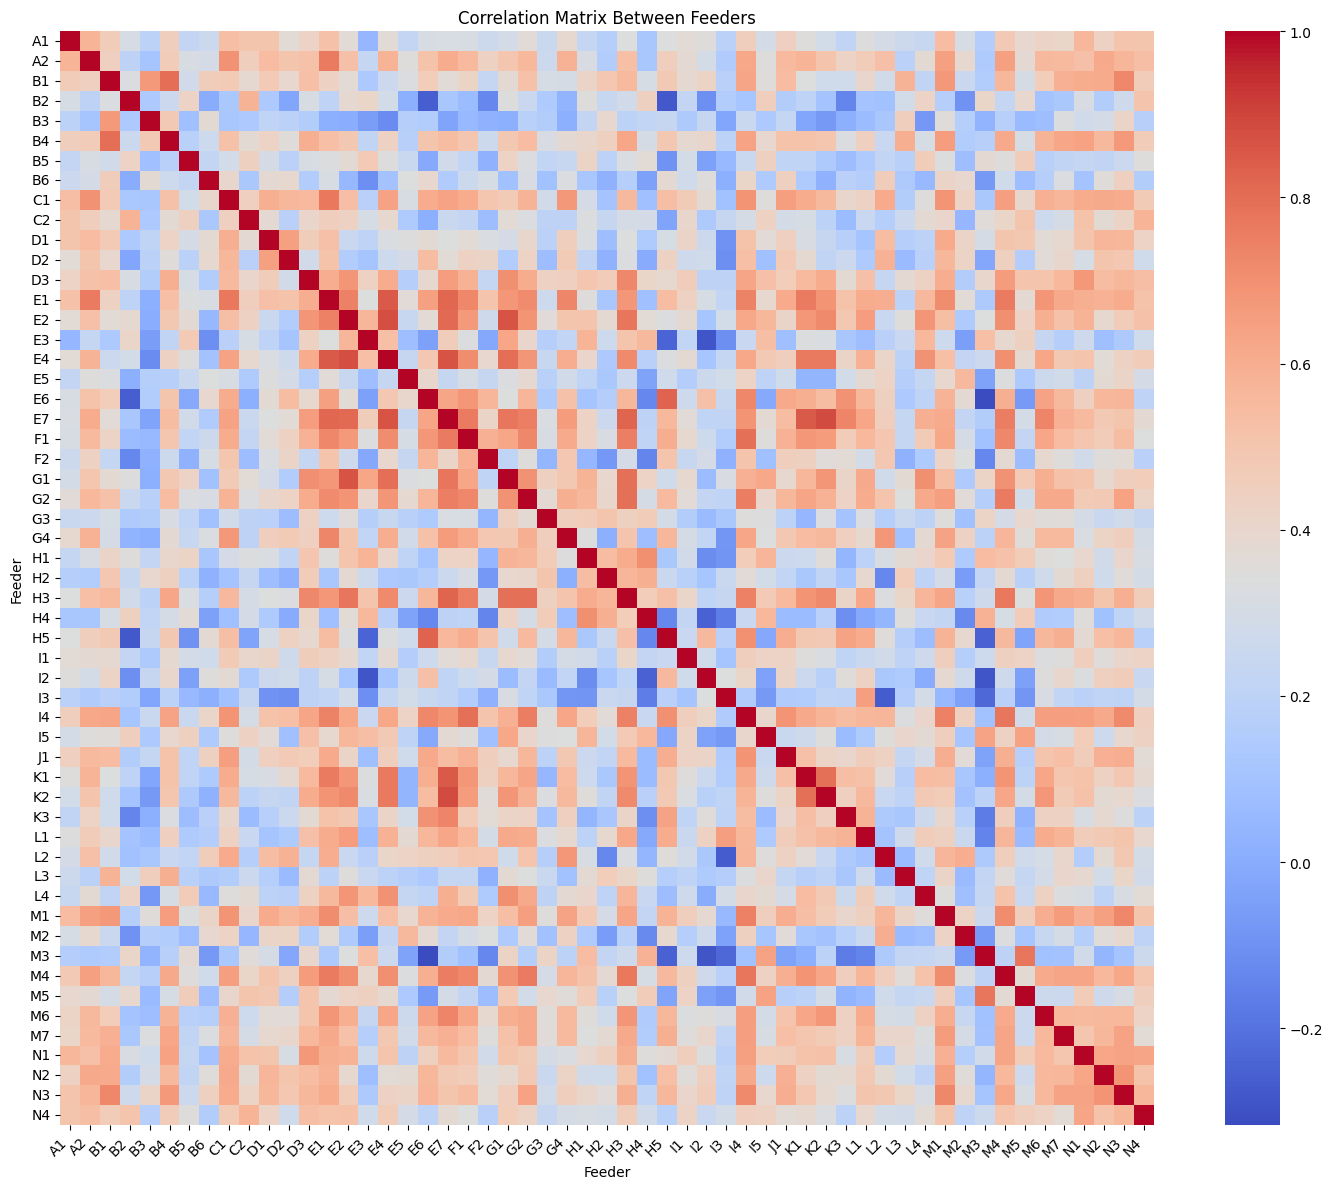

In [6]:


print("Creating pivot table for correlation analysis...")


pivot_df = df.pivot_table(index='datetime', columns='feeder', values='consumption')

# Compute the correlation matrix between feeders
corr_matrix = pivot_df.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    xticklabels=True,
    yticklabels=True
)
plt.title('Correlation Matrix Between Feeders')
plt.xlabel('Feeder')
plt.ylabel('Feeder')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Sort by total consumption

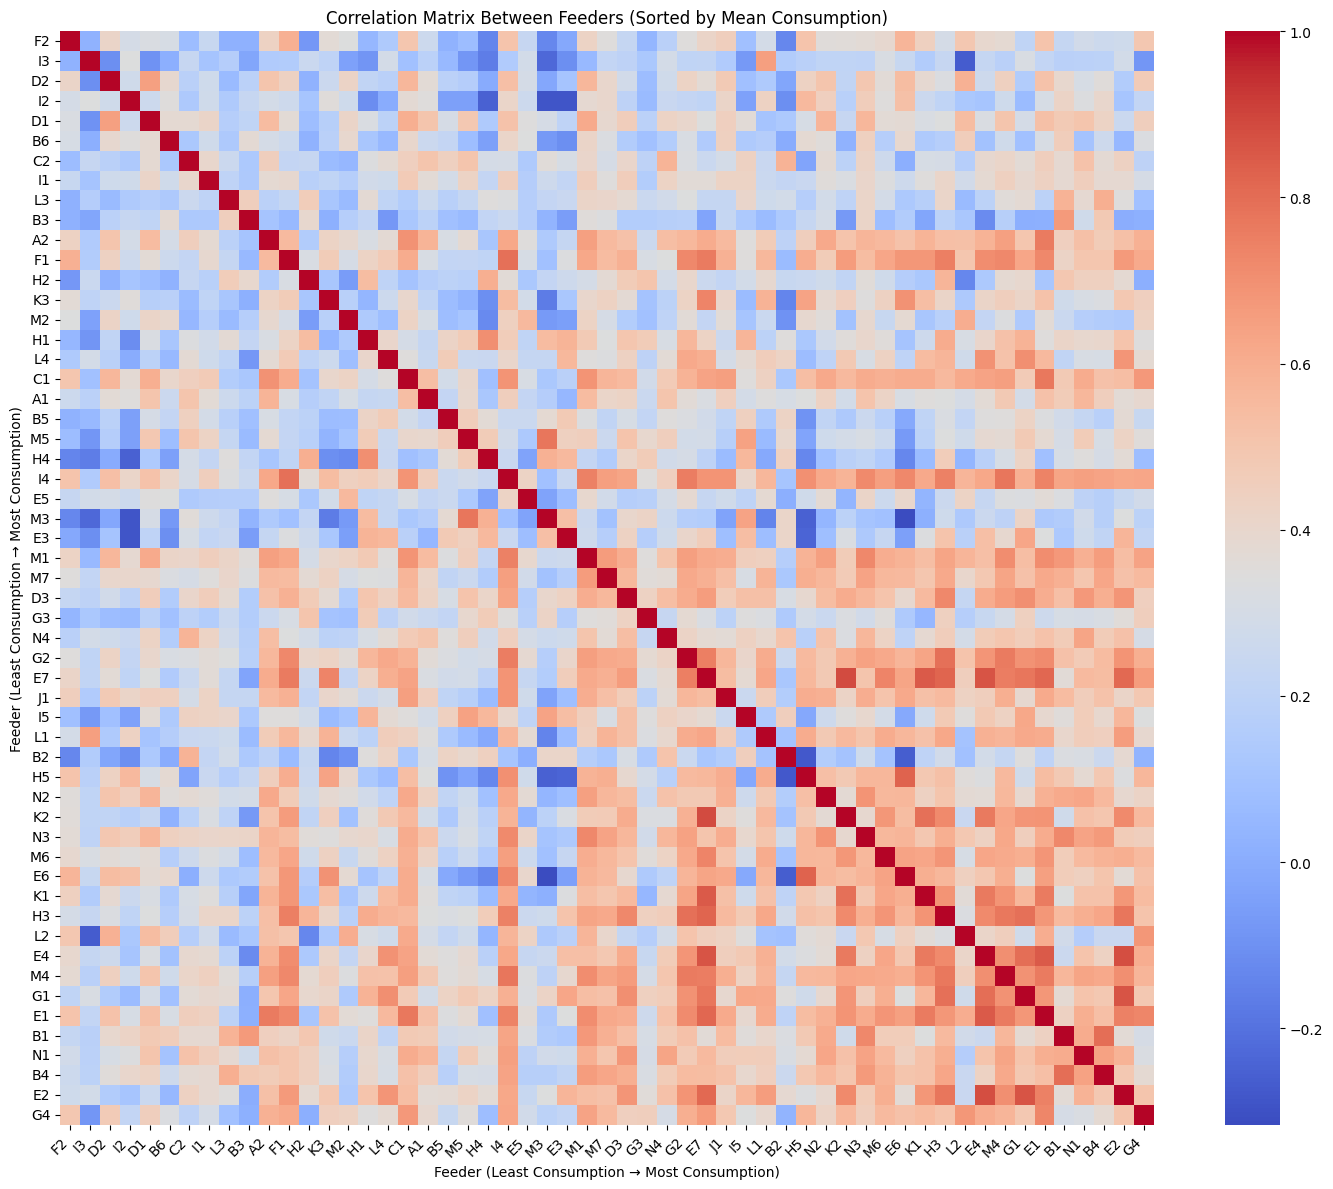

Total number of feeders in correlation matrix: 55
Correlation matrix shape: (55, 55)
Mean consumption range: 11.86 to 198.67


In [14]:
# Compute the mean consumption for each feeder (column) and sort columns by mean consumption (ascending)
# Use skipna=True to handle NaN values properly
mean_consumption = pivot_df.mean(skipna=True)
sorted_columns = mean_consumption.sort_values().index.tolist()

# Plot the correlation matrix with columns sorted by mean consumption
plt.figure(figsize=(15, 12))
corr_matrix = pivot_df[sorted_columns].corr()
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    xticklabels=True,
    yticklabels=True
)
plt.title('Correlation Matrix Between Feeders (Sorted by Mean Consumption)')
plt.xlabel('Feeder (Least Consumption → Most Consumption)')
plt.ylabel('Feeder (Least Consumption → Most Consumption)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary to verify all feeders are included
print(f"Total number of feeders in correlation matrix: {len(sorted_columns)}")
print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Mean consumption range: {mean_consumption.min():.2f} to {mean_consumption.max():.2f}")

In [15]:
# Compute total consumption across all feeders at each time point
total_consumption = pivot_df.sum(axis=1, skipna=True)

# Create a figure with subplots - one for total consumption and one for individual feeders
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot total consumption on the first subplot
ax1.plot(total_consumption.index, total_consumption.values, 'k-', linewidth=2, label='Total Consumption')
ax1.set_title('Total Electricity Consumption Over Time')
ax1.set_ylabel('Total Consumption (kWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Create a color map for feeders based on their mean consumption (gradient)
feeder_means = pivot_df.mean(skipna=True).sort_values()
colors = plt.cm.viridis(np.linspace(0, 1, len(feeder_means)))

# Plot each feeder with gradient colors on the second subplot
for i, (feeder, mean_val) in enumerate(feeder_means.items()):
    feeder_data = pivot_df[feeder].dropna()
    ax2.plot(feeder_data.index, feeder_data.values, 
             color=colors[i], alpha=0.7, linewidth=0.8, label=f'{feeder} (avg: {mean_val:.1f})')

ax2.set_title('Individual Feeder Consumption (Colored by Mean Consumption: Low→High)')
ax2.set_xlabel('Time')
ax2.set_ylabel('Consumption (kWh)')
ax2.grid(True, alpha=0.3)

# Add colorbar to show the gradient mapping
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                          norm=plt.Normalize(vmin=feeder_means.min(), vmax=feeder_means.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label('Mean Consumption (kWh)')

plt.tight_layout()
plt.show()

# Display summary statistics
print(f"Total consumption statistics:")
print(f"Mean: {total_consumption.mean():.2f} kWh")
print(f"Max: {total_consumption.max():.2f} kWh")
print(f"Min: {total_consumption.min():.2f} kWh")
print(f"\nFeeder consumption range:")
print(f"Lowest avg: {feeder_means.iloc[0]:.2f} kWh ({feeder_means.index[0]})")
print(f"Highest avg: {feeder_means.iloc[-1]:.2f} kWh ({feeder_means.index[-1]})")

NameError: name 'np' is not defined

Error in callback <function _draw_all_if_interactive at 0x000002321CB31BC0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

: 

: 

### Sort by correlation between total consumption and each feeder

In [5]:
# Compute correlation between each feeder and total consumption
feeder_total_corr = pivot_df.apply(lambda col: col.corr(total_consumption))

# Sort columns by their correlation with total consumption (ascending order: least to most contributing)
sorted_by_total_corr = feeder_total_corr.sort_values().index.tolist()

# Plot the correlation matrix with columns sorted by contribution to total consumption
plt.figure(figsize=(15, 10))
sns.heatmap(
    pivot_df[sorted_by_total_corr].corr(),
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('Correlation Matrix Between Feeders (Sorted by Contribution to Total Consumption)')
plt.xlabel('Feeder (Least Contributing → Most Contributing)')
plt.ylabel('Feeder (Least Contributing → Most Contributing)')
plt.show()

# Compute correlation between each feeder's time series and the total consumption (sum across all feeders at each time)
total_consumption = pivot_df.sum(axis=1)
feeder_total_corr = pivot_df.apply(lambda col: col.corr(total_consumption))

# Display the correlation values (reverse order - lowest to highest correlation)
feeder_total_corr = feeder_total_corr.sort_values(ascending=True)

plt.figure(figsize=(14, 2))
sns.heatmap(feeder_total_corr.to_frame().T, annot=False, cmap='coolwarm', cbar=True)
plt.title('Correlation of Each Feeder with Total Consumption (Least to Most Contributing)')
plt.yticks([])
plt.xlabel('Feeder')
plt.show()

NameError: name 'total_consumption' is not defined

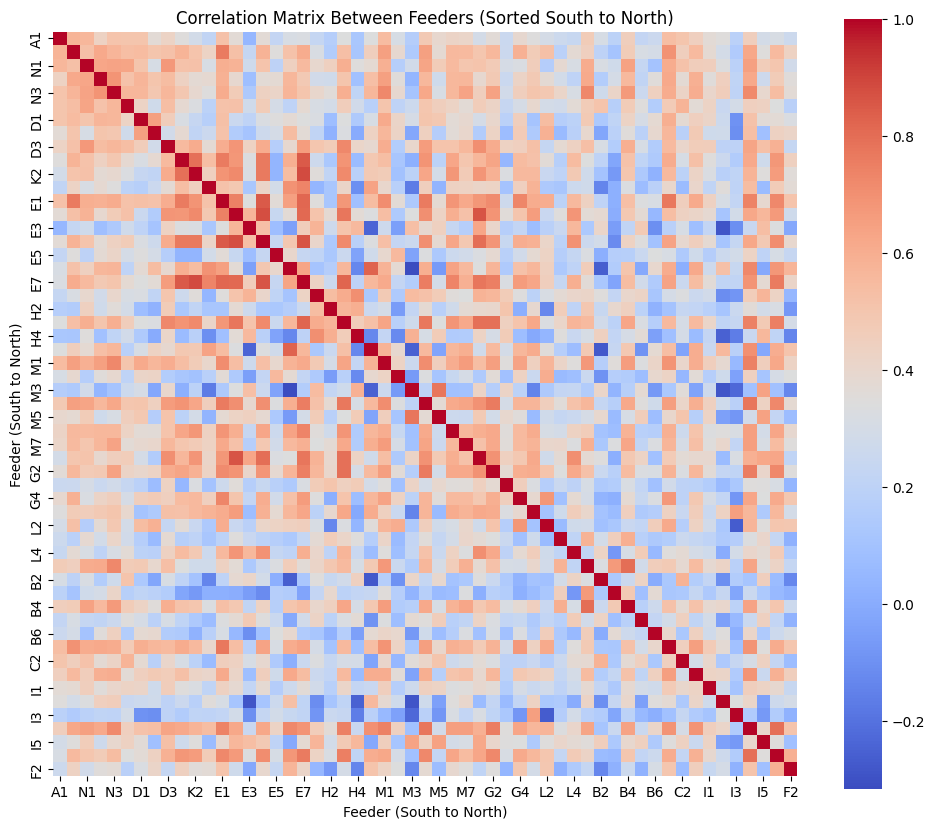

In [ ]:
# Get mapping from substation code (first letter) to latitude
code_to_lat = substations_df.set_index('substation')['latitude'].to_dict()

# For each feeder column, get its first letter and corresponding latitude
feeder_lat = {col: code_to_lat.get(col[0], float('inf')) for col in pivot_df.columns}

# Sort columns by latitude (most south = smallest latitude)
sorted_by_south = sorted(feeder_lat, key=lambda x: feeder_lat[x])

# Plot the correlation matrix with columns sorted by latitude (most south at left)
plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_df[sorted_by_south].corr(),
    annot=False,
    cmap='coolwarm',
    fmt='.2f',
    square=True
)
plt.title('Correlation Matrix Between Feeders (Sorted South to North)')
plt.xlabel('Feeder (South to North)')
plt.ylabel('Feeder (South to North)')
plt.show()

## Correlation between substations

C:\Users\knuto\AppData\Local\Temp\ipykernel_30572\3608782711.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  pivot_df_summed = pivot_df_letters.groupby(axis=1, level=0).sum()


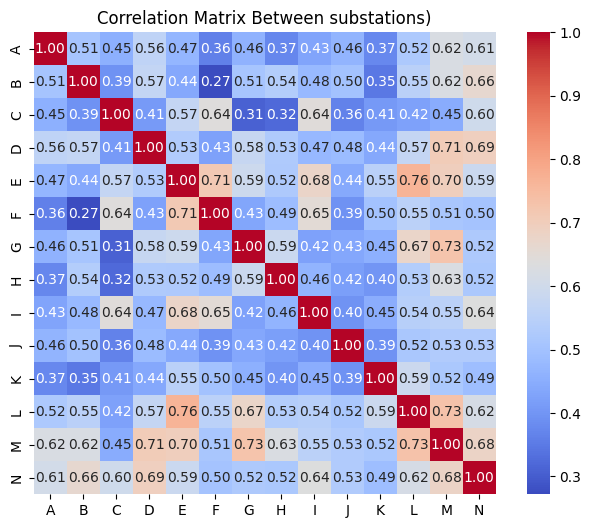

In [ ]:
# Sum up all feeders of the same letter (e.g., A1 and A2 into A)
# Assumes feeder names like 'A1', 'A2', ..., 'B1', 'B2', ...
import re

# Extract the letter part from each feeder name
def get_feeder_letter(feeder_name):
    match = re.match(r'([A-Za-z]+)', str(feeder_name))
    return match.group(1) if match else feeder_name

pivot_df_letters = pivot_df.copy()
pivot_df_letters.columns = [get_feeder_letter(col) for col in pivot_df.columns]

# Sum columns with the same letter (i.e., group by letter)
pivot_df_summed = pivot_df_letters.groupby(axis=1, level=0).sum()

# Compute the correlation matrix for the summed feeders
corr_matrix_letters = pivot_df_summed.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_letters, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix Between substations)')
plt.show()

## Weather correlation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
consumption_path = '../../data/paraguay/electricity-consumption-raw.csv'
weather_path = '../../data/paraguay/meteorological-raw.csv'
substations_path = '../../data/paraguay/substations-geographical-location.csv'

# Load data
df_consumption = pd.read_csv(consumption_path)
df_weather = pd.read_csv(weather_path)
df_substations = pd.read_csv(substations_path)

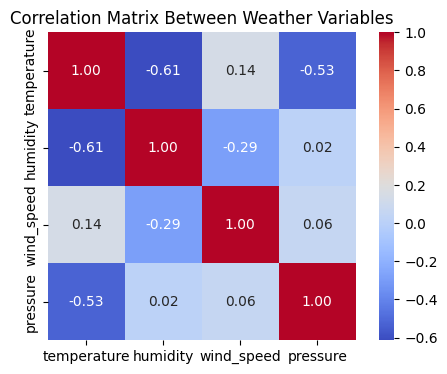

In [ ]:
# Compute the correlation matrix between the weather variables
weather_corr_matrix = merged[weather_cols].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(weather_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix Between Weather Variables')
plt.show()

## Correlation Matrix Between stations and weather variables

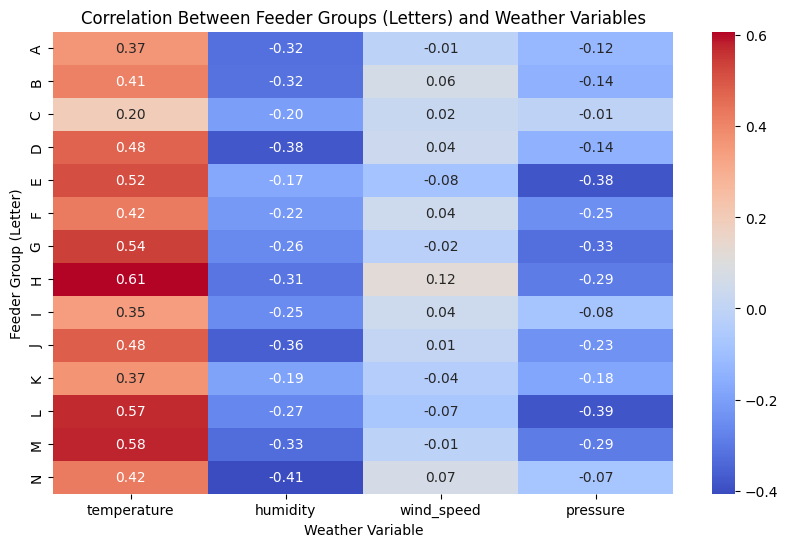

In [ ]:
# Keep only rows in pivot_df_summed that match weather datetimes (every third hour)

# Ensure 'datetime' is a column, not just the index

pivot_df_summed_reset = pivot_df_summed.reset_index()

matching_datetimes = df_weather['datetime']

pivot_df_summed_matched = pivot_df_summed_reset[pivot_df_summed_reset['datetime'].isin(matching_datetimes)]

# Merge on datetime

merged = pd.merge(pivot_df_summed_matched, df_weather, on='datetime', how='inner')

# Select only numeric weather columns (excluding 'datetime')

weather_cols = [col for col in df_weather.columns if col != 'datetime' and pd.api.types.is_numeric_dtype(df_weather[col])]

letter_cols = [col for col in pivot_df_summed.columns if col != 'datetime']

# Compute correlation between each letter and each weather variable

corr_weather = merged[letter_cols + weather_cols].corr().loc[letter_cols, weather_cols]

# Plot heatmap of correlations between feeder groups (letters) and weather variables

plt.figure(figsize=(10, 6))

sns.heatmap(corr_weather, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Between Feeder Groups (Letters) and Weather Variables')

plt.ylabel('Feeder Group (Letter)')

plt.xlabel('Weather Variable')

plt.show()